In [25]:
import ROOT
import os
import glob

In [26]:
fileDirPath = "/d/home/septian/Moments2Amplitudes/brufit/"

file = "result_tree_L4_only.root"
# file = "result_tree_BWa2_freeSWaves_0.root"

In [27]:
f = ROOT.TFile(os.path.join(fileDirPath, file), "READ")

In [28]:
t = f.Get("result")

In [29]:
df = ROOT.RDataFrame("result", f)
col_names = df.GetColumnNames()

In [30]:

amp_col_names = [col for col in col_names if not col.startswith("aphi_") and not col.startswith("bphi_") and not col.startswith("a_0_") and not col.startswith("b_0_") and not col.startswith("a_1_") and not col.startswith("b_1_") and not col.startswith("H_") and not col.startswith("mass_bin")]
print("Amplitude column names:", amp_col_names)

for col in amp_col_names:
    print(f"Column: {col}")

Amplitude column names: [b'a_2_-1', b'a_2_-2', b'a_2_0', b'a_2_1', b'a_2_2', b'b_2_-1', b'b_2_-2', b'b_2_0', b'b_2_1', b'b_2_2']
Column: a_2_-1
Column: a_2_-2
Column: a_2_0
Column: a_2_1
Column: a_2_2
Column: b_2_-1
Column: b_2_-2
Column: b_2_0
Column: b_2_1
Column: b_2_2


In [31]:
mom_col_names = [col for col in col_names if col.startswith("H_0_4") or col.startswith("H_1_4") or col.startswith("H_2_4")]

print("Moment column names:", mom_col_names)
for col in mom_col_names:
    print(f"Column: {col}")

Moment column names: [b'H_0_4_0', b'H_0_4_1', b'H_0_4_2', b'H_0_4_3', b'H_0_4_4', b'H_1_4_0', b'H_1_4_1', b'H_1_4_2', b'H_1_4_3', b'H_1_4_4', b'H_2_4_1', b'H_2_4_2', b'H_2_4_3', b'H_2_4_4']
Column: H_0_4_0
Column: H_0_4_1
Column: H_0_4_2
Column: H_0_4_3
Column: H_0_4_4
Column: H_1_4_0
Column: H_1_4_1
Column: H_1_4_2
Column: H_1_4_3
Column: H_1_4_4
Column: H_2_4_1
Column: H_2_4_2
Column: H_2_4_3
Column: H_2_4_4


In [32]:
import sys
sys.path.append("/d/home/septian/EtaPi0Analysis/jupyter_notebook/")
import BruFitResults as FitResults

In [33]:
fit_result_dir = "/d/home/septian/EtaPi0Analysis/run_merged/fitMoment_GlueX1_2019_11_t010100_m080200_MCMCN6000BI1000S08WCOV_R6.34/"

mass_name = "Mpi0eta"
N_mass_bin = 30
mass_bin_width = 0.04
first_mass_bin_center = 0.82

mass_bin = [first_mass_bin_center + mass_bin_width * i for i in range(N_mass_bin)]
mass_bin_dir = [f"{mass_name}{mass:.6f}_/" for mass in mass_bin]

MCMCResults_Phase1_GlueX2020_nominal = FitResults.MomentsMCMC(fit_result_dir, mass_bin_dir, mass_name)

In [34]:
# MCMCResults_Phase1_GlueX2020_nominal.load_rdf()

In [35]:
# MCMCResults_Phase1_GlueX2020_nominal.load_acceptance()

In [36]:
# MCMCResults_Phase1_GlueX2020_nominal.save_unnormalized_moments_vs_mass(fit_result_dir + "Moments_corrected_unnormalized_vs_mass_Phase1_GlueX2020.root")

In [37]:
def MakeAmplitudeSqrVsMass(tree, amp_name):
    gr = ROOT.TGraph()
    gr.SetName(f"{amp_name}_sqr_vs_mass")
    gr.SetTitle(f"{amp_name} squared vs Mass")
    gr.GetXaxis().SetTitle("Mass (GeV/c^{2})")
    gr.GetYaxis().SetTitle(f"{amp_name} squared (GeV/c^{2})^{2}")
    tree.SetBranchStatus("*", 0)  # Disable all branches
    tree.SetBranchStatus("mass_bin", 1)  # Enable only mass_bin branch
    tree.SetBranchStatus(amp_name, 1)  # Enable the specific amplitude branch
    for entry in tree:
        mass = tree.GetLeaf("mass_bin").GetValue()
        amp_value = tree.GetLeaf(amp_name).GetValue()
        gr.SetPoint(gr.GetN(), mass, amp_value*amp_value)
    return gr

def MakeMomentVsMassGraph(tree, moment_name):
    gr = ROOT.TGraph()
    tree.SetBranchStatus("*", 0)
    tree.SetBranchStatus("mass_bin", 1)
    tree.SetBranchStatus(f"{moment_name}", 1)
    for entry in range(tree.GetEntries()):
        tree.GetEntry(entry)
        mass_bin_value = tree.GetLeaf("mass_bin").GetValue()
        moment_value = tree.GetLeaf(f"{moment_name}").GetValue()/2
        if mass_bin_value >= 0 and mass_bin_value < len(mass_bin):
            gr.SetPoint(gr.GetN(), mass_bin_value, moment_value)
    
    return gr

In [38]:
gr_H_4 = []
for colname in mom_col_names:
    # print(f"Processing column: {colname}")
    gr = MCMCResults_Phase1_GlueX2020_nominal.load_saved_unnormalized_moments_vs_mass(fit_result_dir + "Moments_corrected_unnormalized_vs_mass_Phase1_GlueX2020.root", colname)
    gr_H_4.append(gr)

In [39]:
len(gr_H_4)

14

In [40]:
gr_H_4_mom2amps = []
for colname in mom_col_names:
    gr = MakeMomentVsMassGraph(t, colname)
    gr_H_4_mom2amps.append(gr)

In [41]:
len(gr_H_4_mom2amps)

14

In [42]:
out_pdf_dir = "/d/home/septian/EtaPi0Plot/"

In [ ]:
canvas = ROOT.TCanvas("canvas", "Moments vs Mass", 1800, 600)

canvas.Print(out_pdf_dir + "Moments_vs_Mass_H_4.pdf[")

ROOT.gStyle.SetOptTitle(1)

for j in range(5):
    canvas.Clear()
    canvas.Divide(3, 1)
    for i in range(3):
        if i + 3*j >= len(gr_H_4):
            continue
        canvas.cd(i+1)
        gr_H_4[3*j+i].DrawClone("AP")
        # gr_H_4_mom2amps[i].SetMarkerStyle(2)
        gr_H_4_mom2amps[3*j+i].SetMarkerColor(2)
        gr_H_4_mom2amps[3*j+i].SetLineColor(2)
        gr_H_4_mom2amps[3*j+i].SetLineWidth(2)
        gr_H_4_mom2amps[3*j+i].DrawClone("C same")

        legend = ROOT.TLegend(0.5, 0.7, 0.9, 0.9)
        legend.AddEntry(gr_H_4[3*j+i], "Unnorm. moments", "pl")
        legend.AddEntry(gr_H_4_mom2amps[3*j+i], "Fit", "l")
        legend.SetTextSize(0.035)
        legend.DrawClone("same")
    
    canvas.Update()
    canvas.Print(out_pdf_dir + f"Moments_vs_Mass_H_4.pdf")

canvas.Print(out_pdf_dir + "Moments_vs_Mass_H_4.pdf]")

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas
Info in <TCanvas::Print>: pdf file /d/home/septian/EtaPi0Plot/Moments_vs_Mass_H_4.pdf has been created
Info in <TCanvas::Print>: Current canvas added to pdf file /d/home/septian/EtaPi0Plot/Moments_vs_Mass_H_4.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file /d/home/septian/EtaPi0Plot/Moments_vs_Mass_H_4.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file /d/home/septian/EtaPi0Plot/Moments_vs_Mass_H_4.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file /d/home/septian/EtaPi0Plot/Moments_vs_Mass_H_4.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file /d/home/septian/EtaPi0Plot/Moments_vs_Mass_H_4.pdf
Info in <TCanvas::Print>: pdf file /d/home/septian/EtaPi0Plot/Moments_vs_Mass_H_4.pdf has been closed


In [44]:
gr_H000 = MCMCResults_Phase1_GlueX2020_nominal.load_saved_unnormalized_moments_vs_mass(fit_result_dir + "Moments_corrected_unnormalized_vs_mass_Phase1_GlueX2020.root", "H_0_0_0")

In [45]:
canvas_H000 = ROOT.TCanvas("canvas_H000", "H_0_0_0 vs Mass", 1200, 1200)

gr_H000.Draw("AP")
gr_H000.SetMarkerStyle(20)
gr_H000.SetMarkerSize(1.5)
gr_H000.SetLineWidth(2)
canvas_H000.Update()
canvas_H000.Draw()
canvas_H000.Print(out_pdf_dir + "H_0_0_0_vs_Mass.pdf")

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas_H000
Info in <TCanvas::Print>: pdf file /d/home/septian/EtaPi0Plot/H_0_0_0_vs_Mass.pdf has been created


In [46]:
gr_amp_vs_mass = {}
tree = t
chi2 = f.Get("chi2").GetLeaf("chi2").GetValue()
for amp_name in amp_col_names:
    print(f"Processing amplitude: {amp_name}")
    gr = MakeAmplitudeSqrVsMass(tree, f"{amp_name}")
    gr_amp_vs_mass[f"{amp_name}"] = [chi2, gr]

Processing amplitude: a_2_-1
Processing amplitude: a_2_-2
Processing amplitude: a_2_0
Processing amplitude: a_2_1
Processing amplitude: a_2_2
Processing amplitude: b_2_-1
Processing amplitude: b_2_-2
Processing amplitude: b_2_0
Processing amplitude: b_2_1
Processing amplitude: b_2_2


In [50]:
canvas_a_2 = ROOT.TCanvas("canvas_a_2", "D-waves positive refl amp. squared vs Mass", 3000, 600)
ROOT.gStyle.SetOptTitle(0)

refl_dict = {"a": "+", "b": "-"}
l_dict = {"0": "S", "1": "P", "2": "D", "3": "F", "4": "G"}

col_a_2_names = [col for col in amp_col_names if col.startswith("a_2")]
canvas_a_2.Divide(len(col_a_2_names), 1)
for j,name in enumerate(col_a_2_names):
    canvas_a_2.cd(j+1)
    gr_H000.Draw("AP")  # Draw the H_0_0_0 graph with axis
    gr_H000.GetXaxis().SetRangeUser(0.8, 1.6)
    gr_H000.SetMinimum(0.0)
    gr_H000.SetLineWidth(2)

    ROOT.gPad.SetLeftMargin(0.15)
    ROOT.gPad.SetRightMargin(0.0)
    refl,l,m = name.split("_")
    legend = ROOT.TLegend(0.75, 0.7, 1.0, 0.9)

    legend.AddEntry(gr_H000, "H_{0}(0,0)", "lpe")
    legend.SetTextSize(0.06)
    legend.SetBorderSize(0)
    legend.SetFillColorAlpha(0, 0.0)
    
    # canvas_a_2_2.cd(i + 1)
    chi2, gr = gr_amp_vs_mass[f"{name}"]
    # gr.SetMarkerColor(i + 1)
    gr.SetLineColorAlpha(12, 0.2)
    gr.SetLineWidth(2)
    gr.SetFillColorAlpha(12, 0.2)
    # gr.SetMarkerStyle(20 + i)
    # gr.SetTitle(f"a_2_2 vs Mass (Chi2: {chi2})")
    gr.SetTitle("#chi^{2} = " + f"{chi2:.2f}")
    gr.GetXaxis().SetTitle("M_{#eta#pi^{0}} (GeV/c^{2})")
    gr.GetYaxis().SetTitle(f"|{l_dict[l]}^{{{refl_dict[refl]}}}_{{{m}}}|^{{{2}}}")
    # if i == 0:
    #     gr.Draw("APC")  # Draw the first graph with axis
    # else:
        # gr.DrawClone("PC same")
    gr.DrawClone("CF same")
    legend.AddEntry(gr, f"{l_dict[l]}^{{{refl_dict[refl]}}}_{{{m}}}", "l")
    legend.DrawClone()

# canvas_a_2_2.BuildLegend()
canvas_a_2.Draw()
canvas_a_2.Print(out_pdf_dir + "Mom2Amps_a_2_vs_mass_l4Only_model.pdf")

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas_a_2
Info in <TCanvas::Print>: pdf file /d/home/septian/EtaPi0Plot/Mom2Amps_a_2_vs_mass_l4Only_model.pdf has been created


In [48]:
col_b_2_names = [col for col in amp_col_names if col.startswith("b_2")]

canvas_b_2 = ROOT.TCanvas("canvas_b_2", "D-waves negative refl amp. squared vs Mass", 3000, 600)
canvas_b_2.Divide(len(col_b_2_names), 1)
for j,name in enumerate(col_b_2_names):
    canvas_b_2.cd(j+1)
    gr_H000.Draw("AP")  # Draw the H_0_0_0 graph with axis
    gr_H000.GetXaxis().SetRangeUser(0.8, 1.6)
    gr_H000.SetMinimum(0.0)
    gr_H000.SetLineWidth(2)

    ROOT.gPad.SetLeftMargin(0.15)
    ROOT.gPad.SetRightMargin(0.0)
    refl,l,m = name.split("_")
    legend = ROOT.TLegend(0.75, 0.7, 1.0, 0.9)

    legend.AddEntry(gr_H000, "H_{0}(0,0)", "lpe")
    legend.SetTextSize(0.06)
    legend.SetBorderSize(0)
    legend.SetFillColorAlpha(0, 0.0)
    
    chi2, gr = gr_amp_vs_mass[f"{name}"]
    gr.SetLineColorAlpha(12, 0.2)
    gr.SetLineWidth(2)
    gr.SetFillColorAlpha(12, 0.2)
    gr.SetTitle("#chi^{2} = " + f"{chi2:.2f}")
    gr.GetXaxis().SetTitle("M_{#eta#pi^{0}} (GeV/c^{2})")
    gr.GetYaxis().SetTitle(f"|{l_dict[l]}^{{{refl_dict[refl]}}}_{{{m}}}|^{{{2}}}")
    gr.DrawClone("CF same")
    legend.AddEntry(gr, f"{l_dict[l]}^{{{refl_dict[refl]}}}_{{{m}}}", "l")
    legend.DrawClone()


canvas_b_2.Draw()
canvas_b_2.Print(out_pdf_dir + "Mom2Amps_b_2_vs_mass_l4Only_model.pdf")

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas_b_2
Info in <TCanvas::Print>: pdf file /d/home/septian/EtaPi0Plot/Mom2Amps_b_2_vs_mass_l4Only_model.pdf has been created


In [51]:
multipleFitFileName = "result_tree_L4_only_*.root"
multipleFitFile = []
for file in glob.glob(os.path.join(fileDirPath, multipleFitFileName)):
    print(f"Found file: {file}")
    multipleFitFile.append(file)

Found file: /d/home/septian/Moments2Amplitudes/brufit/result_tree_L4_only_38.root
Found file: /d/home/septian/Moments2Amplitudes/brufit/result_tree_L4_only_84.root
Found file: /d/home/septian/Moments2Amplitudes/brufit/result_tree_L4_only_35.root
Found file: /d/home/septian/Moments2Amplitudes/brufit/result_tree_L4_only_24.root
Found file: /d/home/septian/Moments2Amplitudes/brufit/result_tree_L4_only_85.root
Found file: /d/home/septian/Moments2Amplitudes/brufit/result_tree_L4_only_33.root
Found file: /d/home/septian/Moments2Amplitudes/brufit/result_tree_L4_only_45.root
Found file: /d/home/septian/Moments2Amplitudes/brufit/result_tree_L4_only_80.root
Found file: /d/home/septian/Moments2Amplitudes/brufit/result_tree_L4_only_98.root
Found file: /d/home/septian/Moments2Amplitudes/brufit/result_tree_L4_only_83.root
Found file: /d/home/septian/Moments2Amplitudes/brufit/result_tree_L4_only_79.root
Found file: /d/home/septian/Moments2Amplitudes/brufit/result_tree_L4_only_23.root
Found file: /d/h

In [52]:
tFiles = [ROOT.TFile(file, "READ") for file in multipleFitFile]

In [56]:
def GetChi2FromFile(tFile):
    chi2_tree = tFile.Get("chi2")
    if chi2_tree:
        chi2_tree.GetEntry(0)
        chi2_value = chi2_tree.GetLeaf("chi2").GetValue()
        return chi2_value
    else:
        print(f"No chi2 tree found in {tFile.GetName()}")
        return None

In [57]:
chi2_values = []
for tFile in tFiles:
    chi2_value = GetChi2FromFile(tFile)
    if chi2_value is not None:
        print(f"Chi2 value from {tFile.GetName()}: {chi2_value}")
        chi2_values.append(chi2_value)
    else:
        print(f"Skipping file {tFile.GetName()} due to missing chi2 tree.")

Chi2 value from /d/home/septian/Moments2Amplitudes/brufit/result_tree_L4_only_38.root: 670.2336612428145
Chi2 value from /d/home/septian/Moments2Amplitudes/brufit/result_tree_L4_only_84.root: 670.2336612432489
Chi2 value from /d/home/septian/Moments2Amplitudes/brufit/result_tree_L4_only_35.root: 670.2336612430539
Chi2 value from /d/home/septian/Moments2Amplitudes/brufit/result_tree_L4_only_24.root: 670.2336612444244
Chi2 value from /d/home/septian/Moments2Amplitudes/brufit/result_tree_L4_only_85.root: 670.2336612430272
Chi2 value from /d/home/septian/Moments2Amplitudes/brufit/result_tree_L4_only_33.root: 670.2336612429848
Chi2 value from /d/home/septian/Moments2Amplitudes/brufit/result_tree_L4_only_45.root: 670.2336612428725
Chi2 value from /d/home/septian/Moments2Amplitudes/brufit/result_tree_L4_only_80.root: 670.2336612428131
Chi2 value from /d/home/septian/Moments2Amplitudes/brufit/result_tree_L4_only_98.root: 670.2336612430557
Chi2 value from /d/home/septian/Moments2Amplitudes/bruf

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas_chi2
Warning in <TFile::Append>: Replacing existing TH1: h1_chi2 (Potential memory leak).


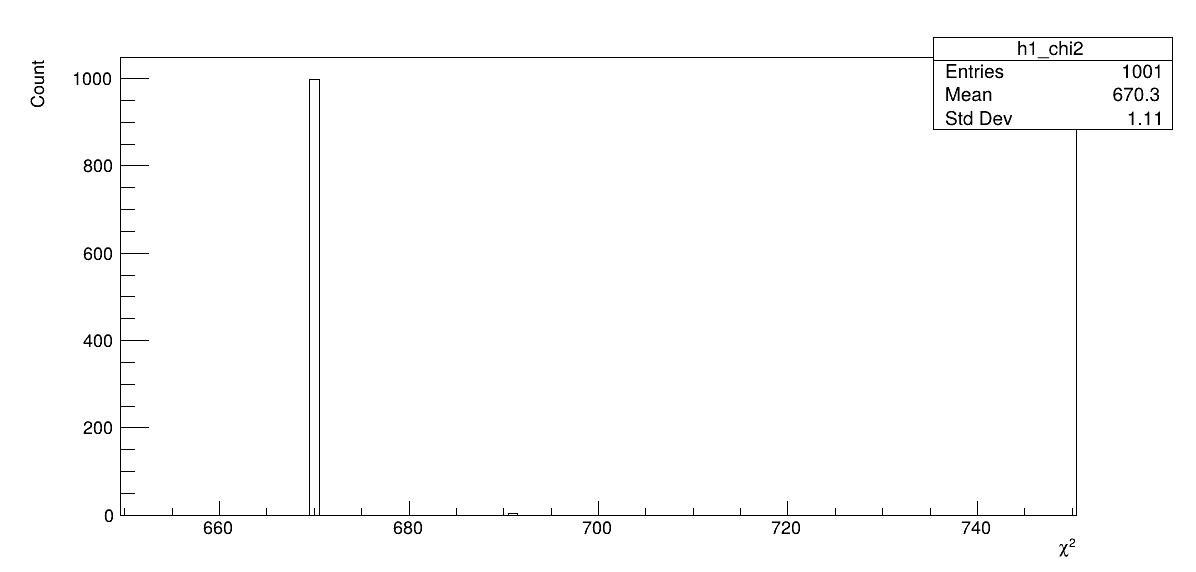

In [65]:
# draw chi2 values
canvas_chi2 = ROOT.TCanvas("canvas_chi2", "Chi2 Values", 1200, 600)
# canvas_chi2.SetGrid()
h1_chi2 = ROOT.TH1D("h1_chi2", "Chi2 Values;#chi^{2};Count", 101, 649.5, 750.5)
for i, chi2 in enumerate(chi2_values):
    h1_chi2.SetLineColor(ROOT.kBlack)
    h1_chi2.Fill(chi2)

h1_chi2.Draw()
canvas_chi2.Draw()

In [70]:
# get the tree with 20 lowest chi2 values
lowest_chi2 = sorted(zip(chi2_values, tFiles), key=lambda x: x[0])[:20]
lowest_chi2_files = [file for _, file in lowest_chi2]

In [71]:
lowest_chi2_files[0]

In [74]:
gr_H_4_mom2amps_iter = []
for tFile in lowest_chi2_files:
    gr_H_4_mom2amps = []
    t = tFile.Get("result")
    for colname in mom_col_names:
        gr = MakeMomentVsMassGraph(t, colname)
        gr_H_4_mom2amps.append(gr)
    gr_H_4_mom2amps_iter.append(gr_H_4_mom2amps)

In [75]:
canvas = ROOT.TCanvas("canvas", "Moments vs Mass", 1800, 600)

canvas.Print(out_pdf_dir + "Moments_vs_Mass_H_4_multiplefits.pdf[")

ROOT.gStyle.SetOptTitle(1)

for j in range(5):
    canvas.Clear()
    canvas.Divide(3, 1)
    for i in range(3):
        if i + 3*j >= len(gr_H_4):
            continue
        canvas.cd(i+1)
        gr_H_4[3*j+i].DrawClone("AP")
        # gr_H_4_mom2amps[i].SetMarkerStyle(2)
        for gr in gr_H_4_mom2amps_iter:
            # gr[i].SetMarkerColor(2)
            gr[3*j+i].SetLineColorAlpha(2,0.2)
            gr[3*j+i].SetLineWidth(2)
            gr[3*j+i].DrawClone("C same")

        legend = ROOT.TLegend(0.5, 0.7, 0.9, 0.9)
        legend.AddEntry(gr_H_4[3*j+i], "Unnorm. moments", "pl")
        legend.AddEntry(gr_H_4_mom2amps[3*j+i], "Fit", "l")
        legend.SetTextSize(0.035)
        legend.DrawClone("same")
    
    canvas.Update()
    canvas.Print(out_pdf_dir + f"Moments_vs_Mass_H_4_multiplefits.pdf")

canvas.Print(out_pdf_dir + "Moments_vs_Mass_H_4_multiplefits.pdf]")

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas
Info in <TCanvas::Print>: Current canvas added to pdf file /d/home/septian/EtaPi0Plot/Moments_vs_Mass_H_4_multiplefits.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file /d/home/septian/EtaPi0Plot/Moments_vs_Mass_H_4_multiplefits.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file /d/home/septian/EtaPi0Plot/Moments_vs_Mass_H_4_multiplefits.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file /d/home/septian/EtaPi0Plot/Moments_vs_Mass_H_4_multiplefits.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file /d/home/septian/EtaPi0Plot/Moments_vs_Mass_H_4_multiplefits.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file /d/home/septian/EtaPi0Plot/Moments_vs_Mass_H_4_multiplefits.pdf
Info in <TCanvas::Print>: pdf file /d/home/septian/EtaPi0Plot/Moments_vs_Mass_H_4_multiplefits.pdf has been closed


In [ ]:
canvas_a_2 = ROOT.TCanvas("canvas_a_2", "D-waves positive refl amp. squared vs Mass", 3000, 600)
ROOT.gStyle.SetOptTitle(0)

refl_dict = {"a": "+", "b": "-"}
l_dict = {"0": "S", "1": "P", "2": "D", "3": "F", "4": "G"}

col_a_2_names = [col for col in amp_col_names if col.startswith("a_2")]
canvas_a_2.Divide(len(col_a_2_names), 1)
for j,name in enumerate(col_a_2_names):
    canvas_a_2.cd(j+1)
    gr_H000.Draw("AP")  # Draw the H_0_0_0 graph with axis
    gr_H000.GetXaxis().SetRangeUser(0.8, 1.6)
    gr_H000.SetMinimum(0.0)
    gr_H000.SetLineWidth(2)

    ROOT.gPad.SetLeftMargin(0.15)
    ROOT.gPad.SetRightMargin(0.0)
    refl,l,m = name.split("_")
    legend = ROOT.TLegend(0.75, 0.7, 1.0, 0.9)

    legend.AddEntry(gr_H000, "H_{0}(0,0)", "lpe")
    legend.SetTextSize(0.06)
    legend.SetBorderSize(0)
    legend.SetFillColorAlpha(0, 0.0)
    
    # canvas_a_2_2.cd(i + 1)
    # chi2, gr = gr_amp_vs_mass[f"{name}"]
    # gr.SetMarkerColor(i + 1)
    gr.SetLineColorAlpha(12, 0.2)
    gr.SetLineWidth(2)
    gr.SetFillColorAlpha(12, 0.2)
    # gr.SetMarkerStyle(20 + i)
    # gr.SetTitle(f"a_2_2 vs Mass (Chi2: {chi2})")
    gr.SetTitle("#chi^{2} = " + f"{chi2:.2f}")
    gr.GetXaxis().SetTitle("M_{#eta#pi^{0}} (GeV/c^{2})")
    gr.GetYaxis().SetTitle(f"|{l_dict[l]}^{{{refl_dict[refl]}}}_{{{m}}}|^{{{2}}}")
    # if i == 0:
    #     gr.Draw("APC")  # Draw the first graph with axis
    # else:
        # gr.DrawClone("PC same")
    gr.DrawClone("CF same")
    legend.AddEntry(gr, f"{l_dict[l]}^{{{refl_dict[refl]}}}_{{{m}}}", "l")
    legend.DrawClone()

# canvas_a_2_2.BuildLegend()
canvas_a_2.Draw()
canvas_a_2.Print(out_pdf_dir + "Mom2Amps_a_2_vs_mass_l4Only_model.pdf")